In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/in-context-learning/src


/content/drive/MyDrive/in-context-learning/src


In [4]:
!pip install munch
# should change import imp to import importlib

In [12]:
from moe import TransformerModel_var_moe
import torch
from tasks import get_task_sampler
from samplers import get_data_sampler

device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransformerModel_var_moe(
    num_experts=4,
    n_dims=1,
    n_positions=81,
    n_embd=128,
    n_layer=6,
    n_head=4
).to(device)

ckpt_path = "../models/polynomial_regression/moe/model_0.pt"
ckpt = torch.load(ckpt_path, map_location=device)

# strict=False 避免 num_experts/top_k 不一致报错
missing, unexpected = model.load_state_dict(ckpt)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
print(model)

Missing keys: []
Unexpected keys: []
TransformerModel_var_moe(
  (_read_in): Linear(in_features=1, out_features=128, bias=True)
  (_backbone): CustomGPT2Model(
    (wte): Embedding(50257, 128)
    (wpe): Embedding(162, 128)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=384, nx=128)
          (c_proj): Conv1D(nf=128, nx=128)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MoEMLP(
          (experts): ModuleList(
            (0-3): 4 x Sequential(
              (0): Linear(in_features=128, out_features=256, bias=True)
              (1): GELU(approximate='none')
              (2): Linear(in_features=256, out_features=128, bias=True)
            )
          )


Global expert usage: [0.1512508  0.2390723  0.47590908 0.13376777]
Layer expert usage shape: (6, 4)


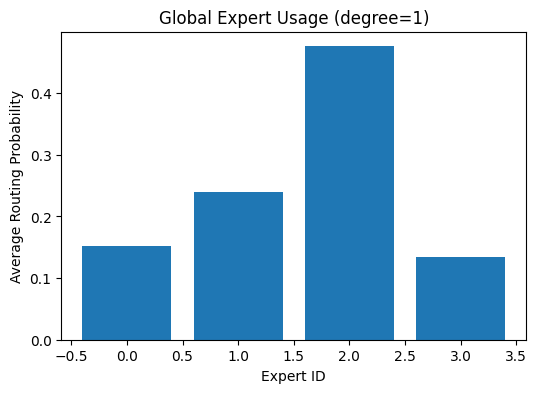

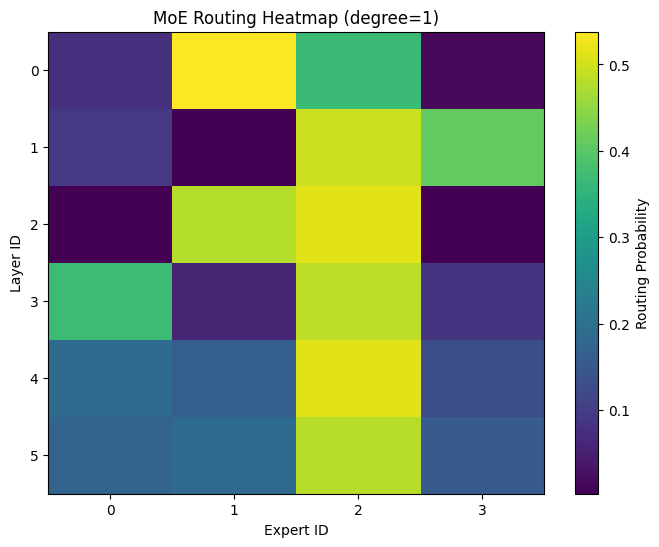

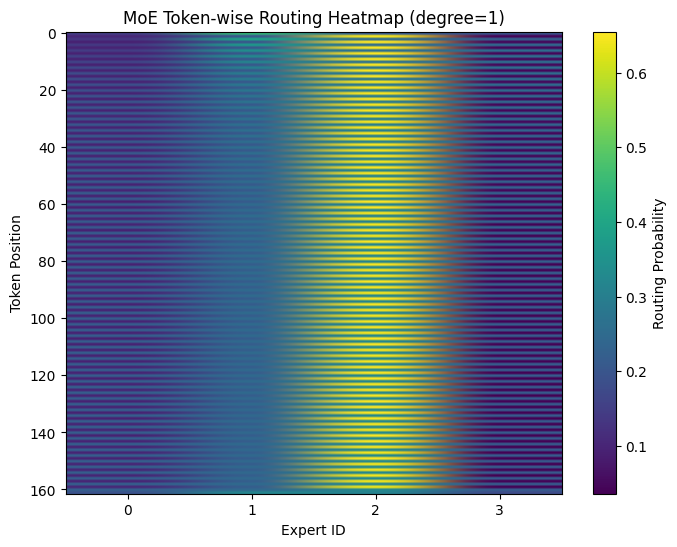

Global expert usage: [0.153399   0.23755455 0.47501358 0.13403286]
Layer expert usage shape: (6, 4)


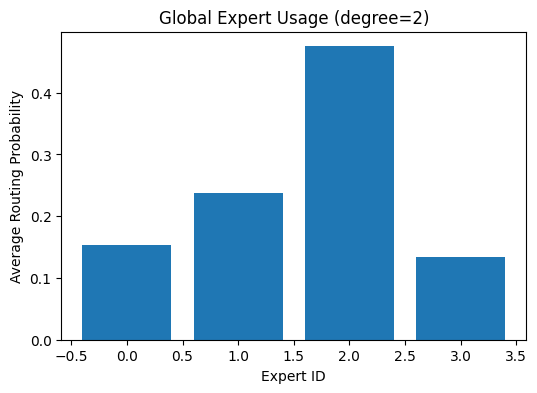

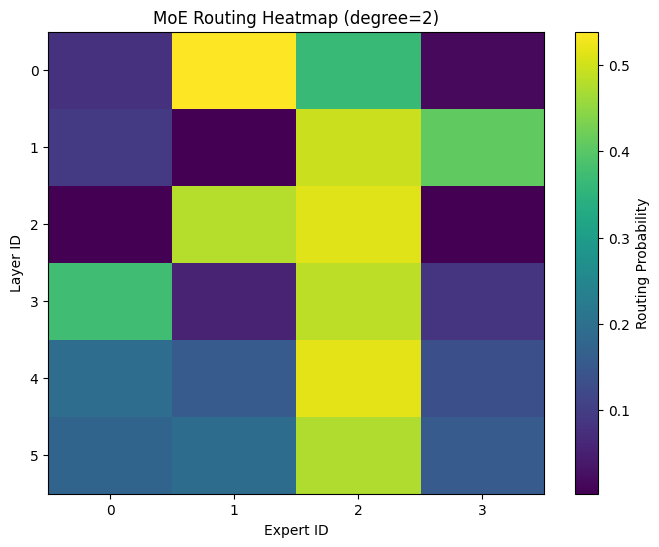

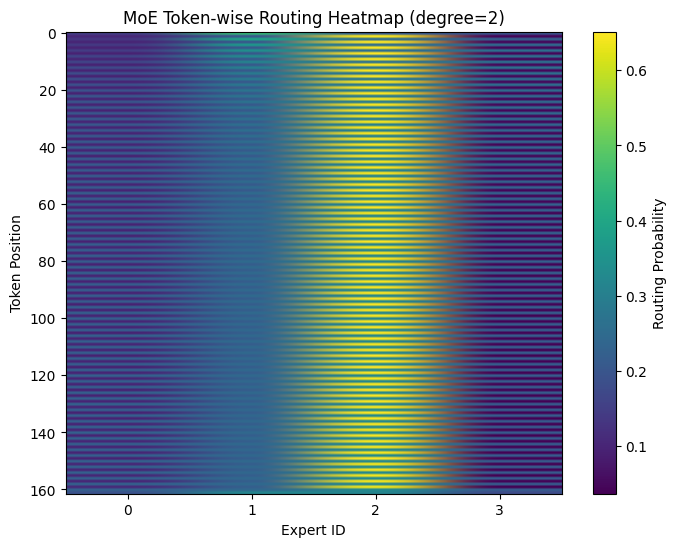

Global expert usage: [0.15408787 0.23630528 0.4752708  0.13433602]
Layer expert usage shape: (6, 4)


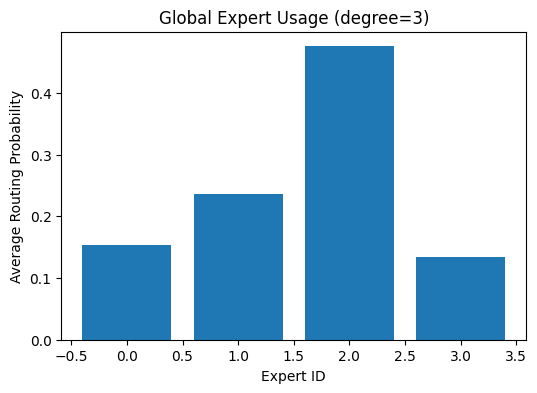

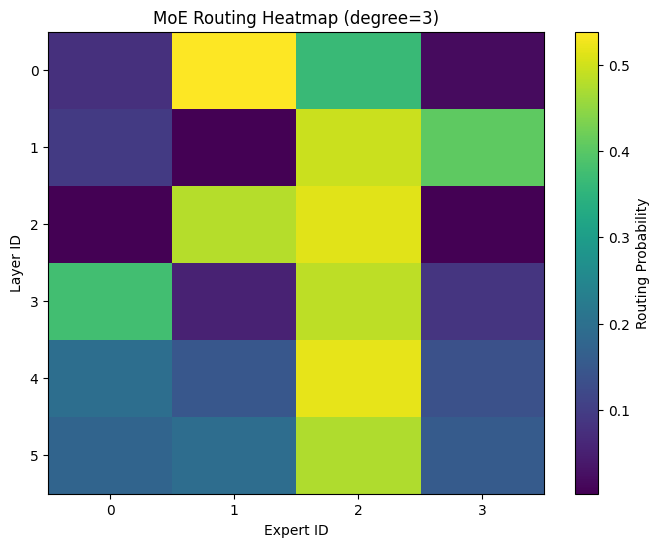

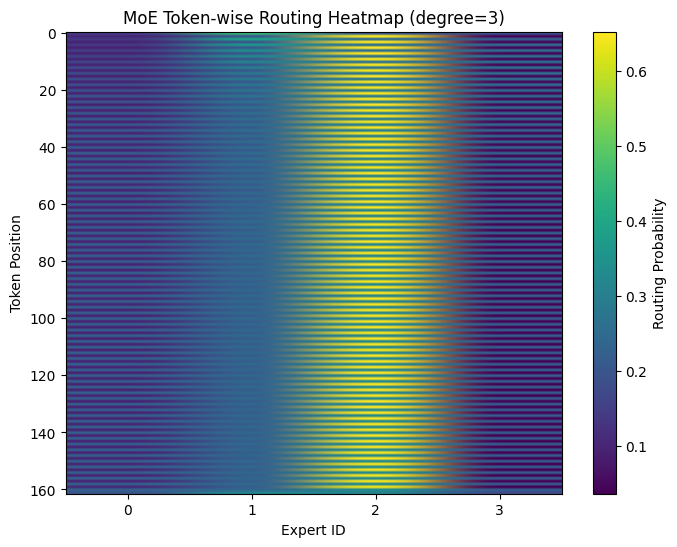

Global expert usage: [0.15502088 0.23594208 0.4745171  0.13451996]
Layer expert usage shape: (6, 4)


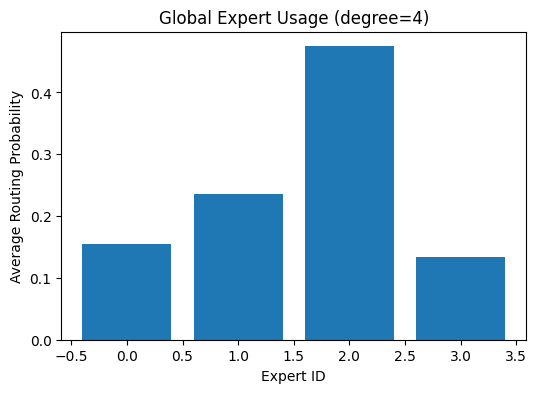

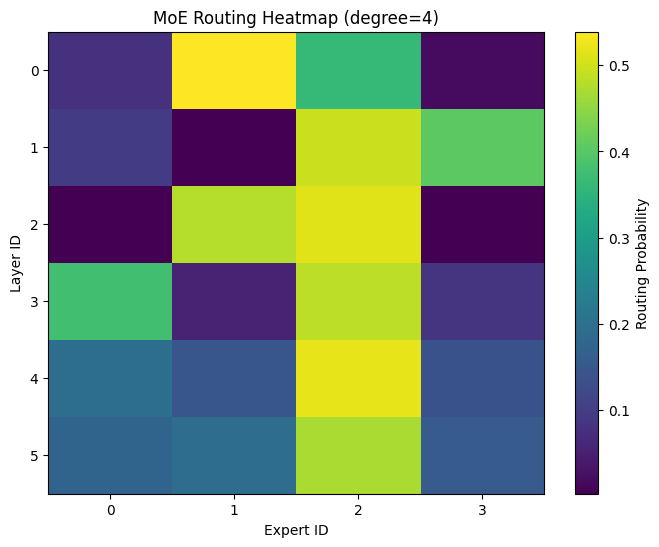

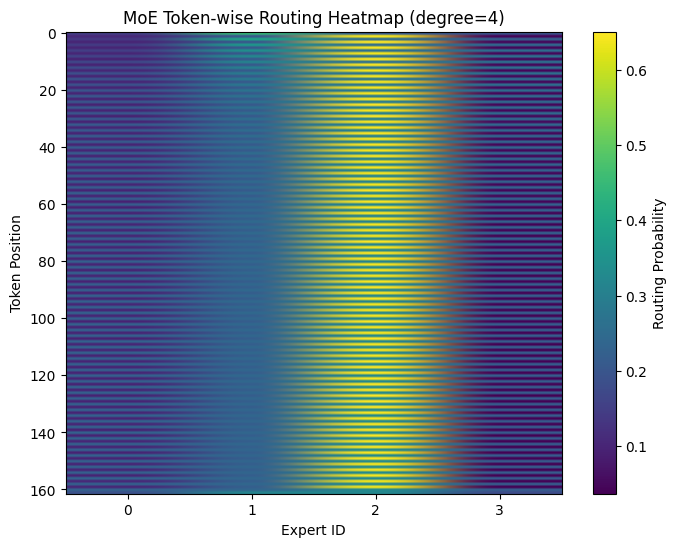

Global expert usage: [0.15551457 0.23510294 0.47463208 0.13475047]
Layer expert usage shape: (6, 4)


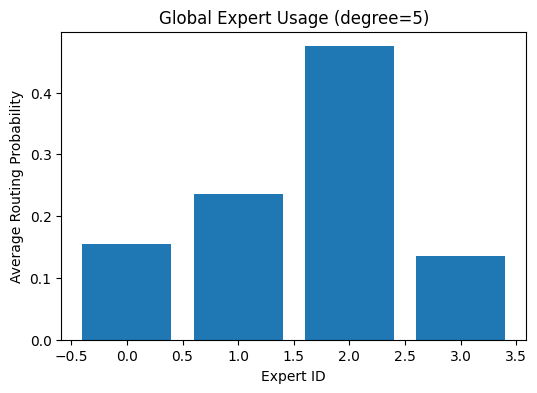

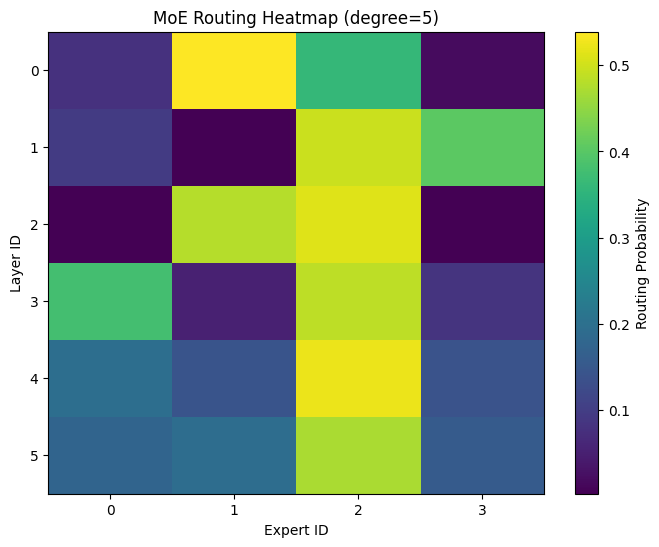

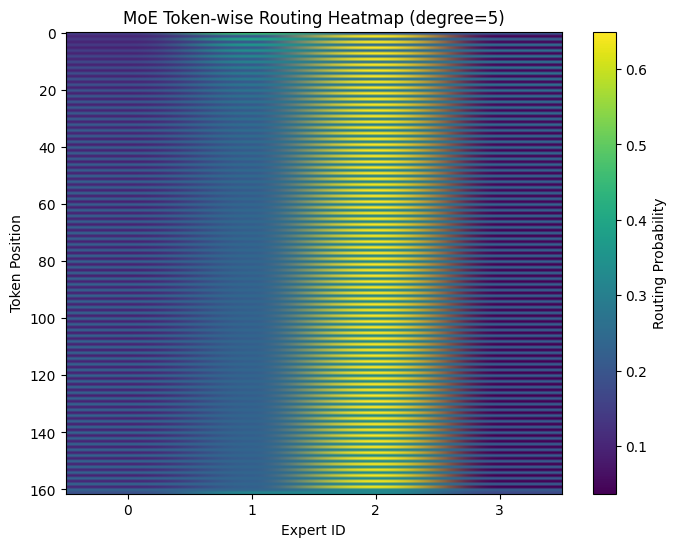

Global expert usage: [0.15546665 0.23500225 0.47473288 0.13479823]
Layer expert usage shape: (6, 4)


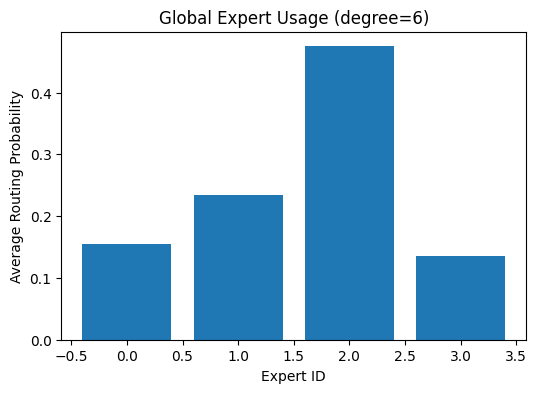

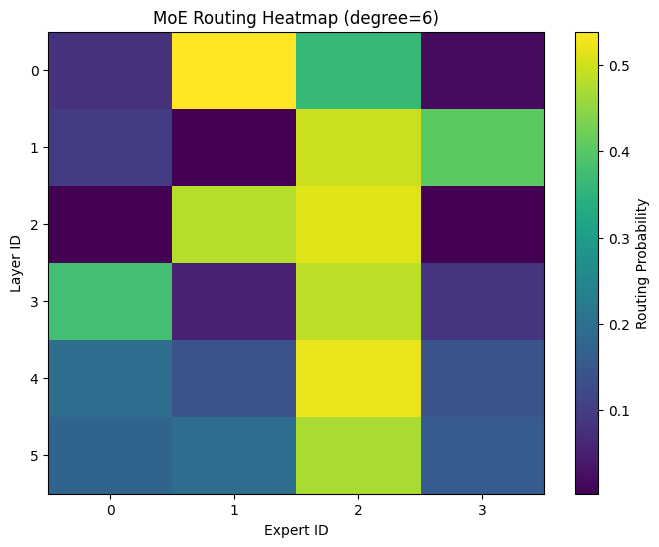

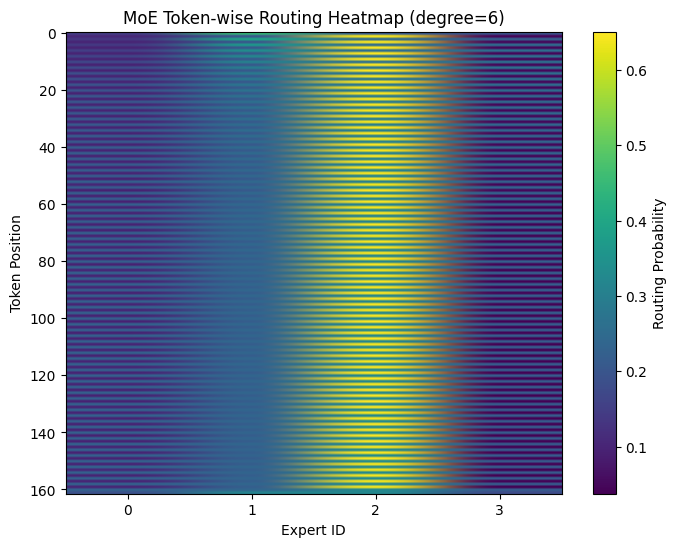

Global expert usage: [0.1564038  0.23447183 0.4743084  0.13481598]
Layer expert usage shape: (6, 4)


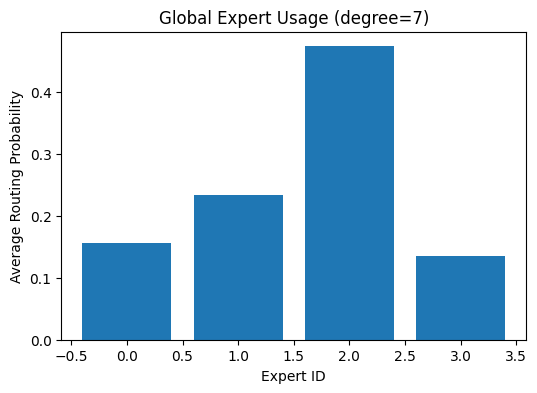

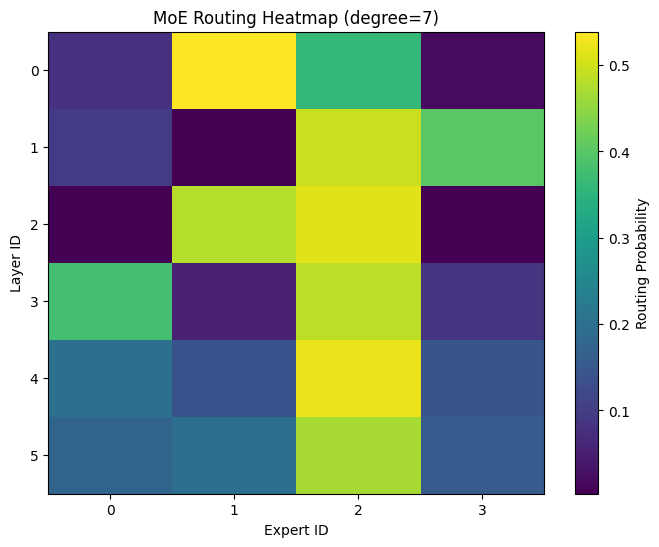

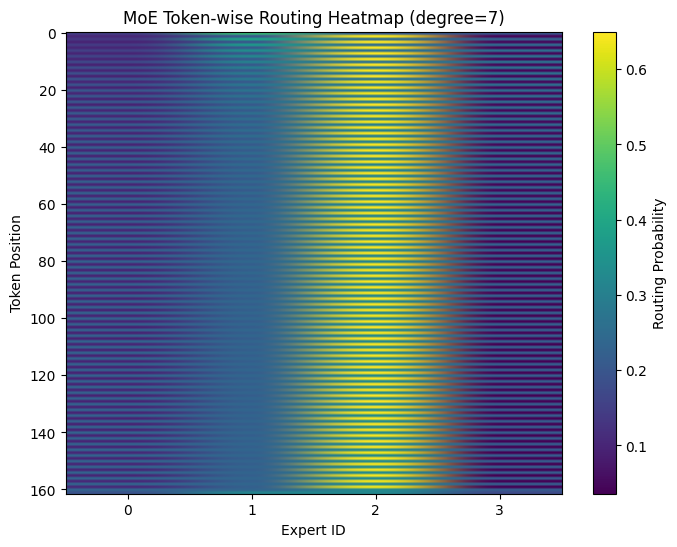

Global expert usage: [0.15642905 0.2345397  0.47426414 0.13476709]
Layer expert usage shape: (6, 4)


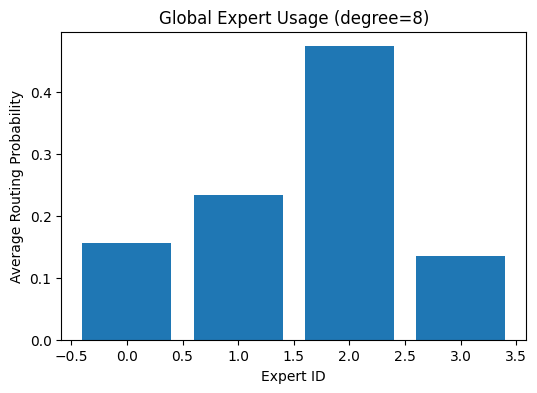

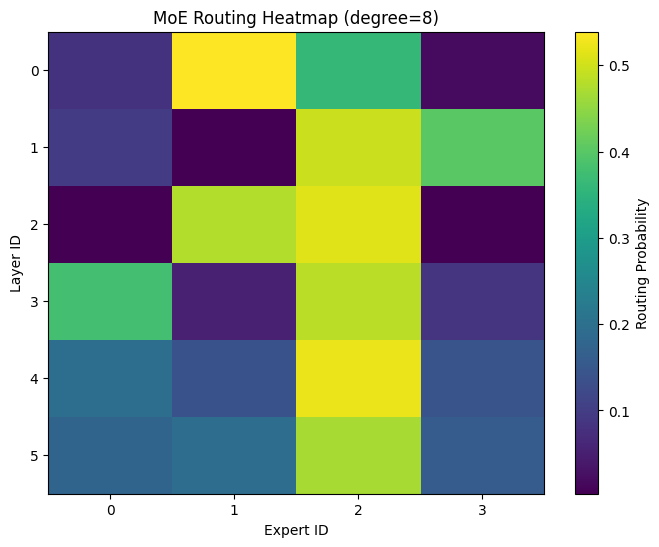

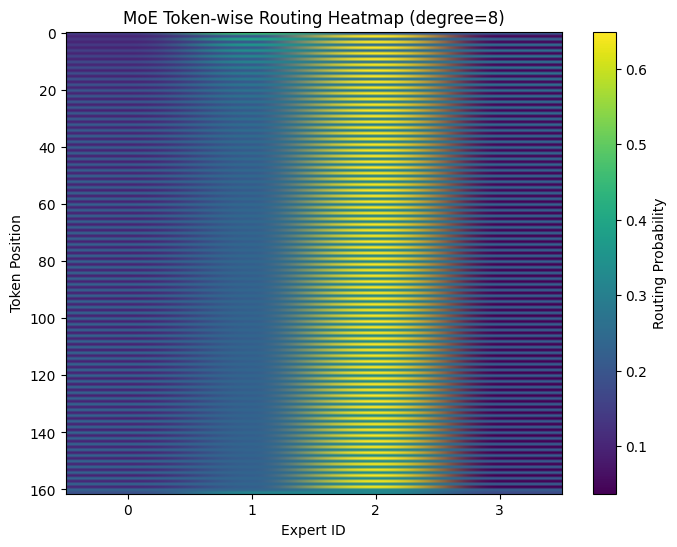

Global expert usage: [0.15656345 0.2341336  0.47464785 0.1346551 ]
Layer expert usage shape: (6, 4)


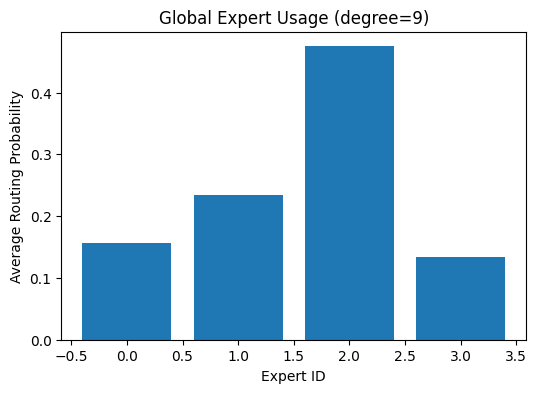

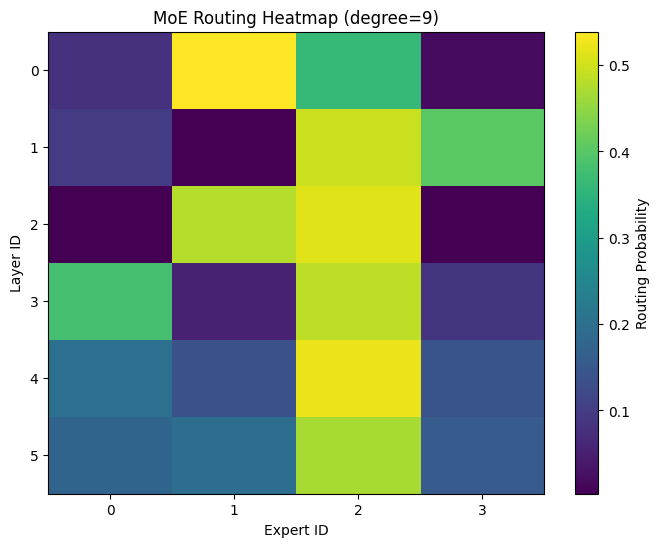

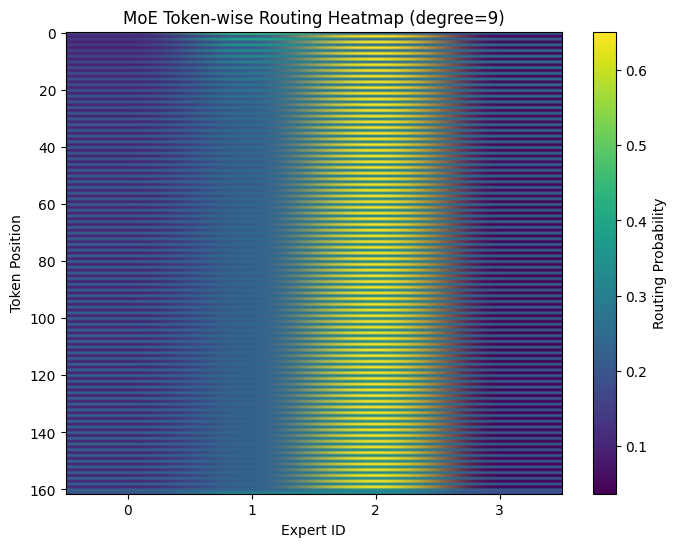

Global expert usage: [0.15717696 0.23361456 0.4743742  0.1348343 ]
Layer expert usage shape: (6, 4)


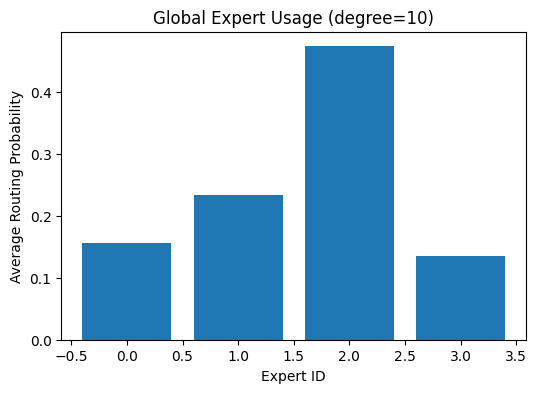

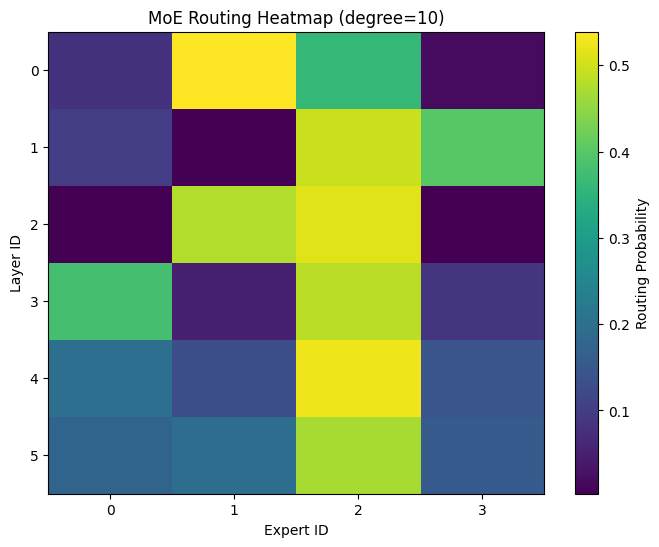

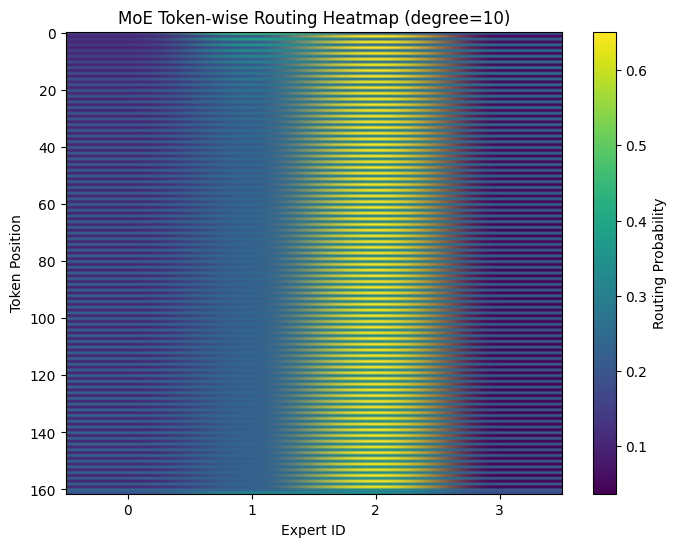

Global expert usage: [0.15770435 0.23360446 0.47397423 0.13471696]
Layer expert usage shape: (6, 4)


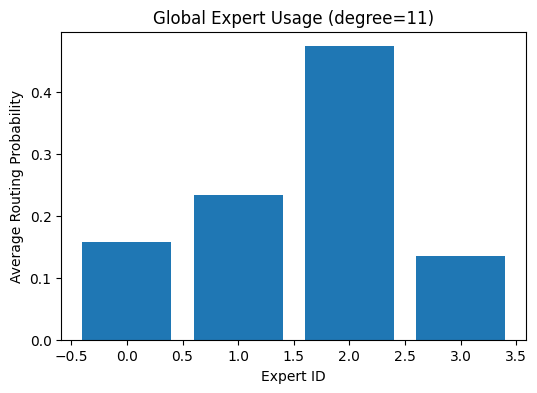

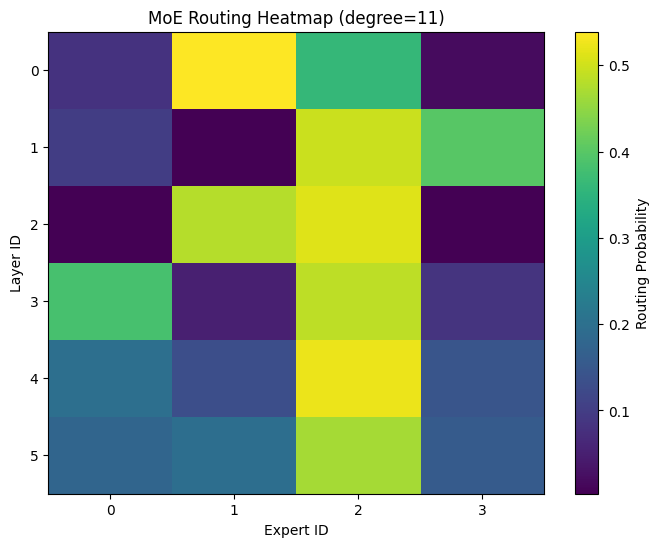

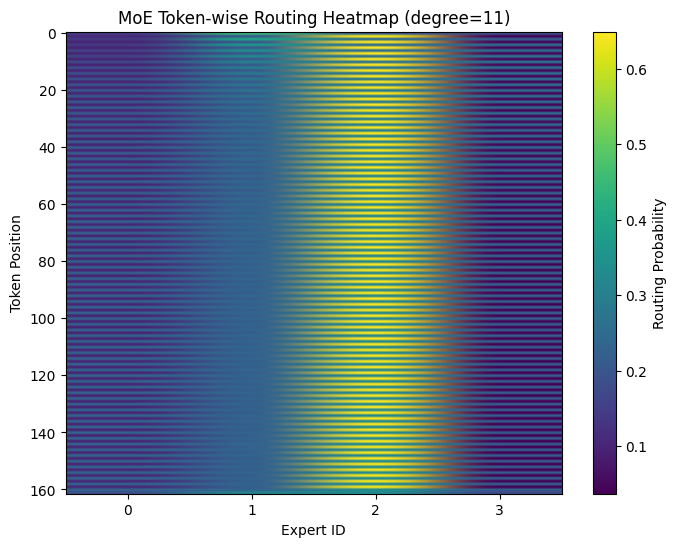

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------
# Global seed for reproducibility
# -----------------------------
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
# -----------------------------

model.eval()

def sample_polynomial_batch(degree, batch_size=64, n_points=81):
    """
    随机生成多项式任务 batch
    xs: [B, N, 1]
    ys: [B, N]
    """
    coeffs = torch.randn(batch_size, degree + 1)   # reproducible
    xs = torch.rand(batch_size, n_points, 1) * 2 - 1   # [-1, 1]
    ys = torch.zeros(batch_size, n_points)

    for d in range(degree + 1):
        ys += coeffs[:, d:d+1] * xs.squeeze(-1) ** d

    return xs, ys


def measure_expert_usage(degree, batches=20, batch_size=64):
    """
    return:
        expert_global_mean: [E]
        expert_layer_mean:  [L, E]
    """

    expert_sum = None
    gate_layer_sum = None
    gate_token_sum=None
    count = 0

    for _ in range(batches):
        xs, ys = sample_polynomial_batch(degree, batch_size=batch_size)

        with torch.no_grad():
            preds, gate_list = model(xs, ys, return_gates=True)

        # gate_list: list[L], each [B, S, E]
        gates_all_layers = torch.stack(gate_list, dim=0)  # [L, B, S, E]

        # ---- 全局平均（所有 token、batch、层）----
        gate_mean_global = gates_all_layers.mean(dim=(0, 1, 2))  # [E]

        if expert_sum is None:
            expert_sum = gate_mean_global
        else:
            expert_sum += gate_mean_global

        #layer level
        gate_mean_per_layer = gates_all_layers.mean(dim=(1, 2))  # [L, E]

        if gate_layer_sum is None:
            gate_layer_sum = gate_mean_per_layer
        else:
            gate_layer_sum += gate_mean_per_layer

        #token level
        gate_mean_per_token = gates_all_layers.mean(dim=(0,1))  # [S, E]

        if gate_token_sum is None:
            gate_token_sum = gate_mean_per_token
        else:
            gate_token_sum += gate_mean_per_token

        count += 1

    expert_global_mean = (expert_sum / count).cpu().numpy()       # [E]
    expert_layer_mean = (gate_layer_sum / count).cpu().numpy()    # [L, E]
    expert_token_mean = (gate_token_sum / count).cpu().numpy()    # [S, E]
    return expert_global_mean, expert_layer_mean,expert_token_mean


# --------------------------------------
# 指定要分析的 degree
# --------------------------------------
for i in range(1,12):
  degree_to_test = i

  expert_global_mean, expert_layer_mean,expert_token_mean = measure_expert_usage(degree=degree_to_test)

  print("Global expert usage:", expert_global_mean)
  print("Layer expert usage shape:", expert_layer_mean.shape)


  save_dir="/content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/expert_plots/"
  # --------------------------------------
  # (1) 画全局 expert 使用率
  # --------------------------------------
  plt.figure(figsize=(6,4))
  plt.bar(np.arange(len(expert_global_mean)), expert_global_mean)
  plt.xticks(np.arange(num_experts), np.arange(num_experts))

  plt.xlabel("Expert ID")
  plt.ylabel("Average Routing Probability")
  plt.title(f"Global Expert Usage (degree={degree_to_test})")
  #plt.savefig(save_dir+f"global_usage_degree_{degree_to_test}.png", dpi=300, bbox_inches="tight")
  plt.show()


  # --------------------------------------
  # (2) 画每层 heatmap
  # --------------------------------------
  plt.figure(figsize=(8,6))
  plt.imshow(expert_layer_mean, cmap="viridis", aspect="auto")
  plt.colorbar(label="Routing Probability")
  plt.xticks(np.arange(num_experts), np.arange(num_experts))

  plt.xlabel("Expert ID")
  plt.ylabel("Layer ID")
  plt.title(f"MoE Routing Heatmap (degree={degree_to_test})")
  plt.savefig(save_dir+f"heatmap_degree_{degree_to_test}.png", dpi=300, bbox_inches="tight")
  plt.show()


  plt.figure(figsize=(8,6))
  plt.imshow(expert_token_mean, cmap="viridis", aspect="auto")
  plt.colorbar(label="Routing Probability")

  num_experts = expert_token_mean.shape[1]
  plt.xticks(np.arange(num_experts), np.arange(num_experts))

  plt.xlabel("Expert ID")
  plt.ylabel("Token Position")
  plt.title(f"MoE Token-wise Routing Heatmap (degree={degree_to_test})")

  plt.savefig(save_dir + f"token_level_degree_{degree_to_test}.png", dpi=300, bbox_inches="tight")
  plt.show()

In [ ]:
# 测 degree = 1 到 12
max_degree = 11
results = []

for deg in range(1, max_degree + 1):
    usage,_ = measure_expert_usage(degree=deg)
    results.append(usage)
    print(f"Degree {deg}: {usage}")

results = np.array(results)   # [D, E]
num_experts = results.shape[1]

plt.figure(figsize=(8,5))
for e in range(num_experts):
    plt.plot(results[:, e], label=f"Expert {e}", linewidth=2)

plt.xlabel("Polynomial Degree")
plt.ylabel("Average Routing Probability")
plt.title("MoE Expert Usage vs Polynomial Degree")
plt.savefig(save_dir+f"MoE_Expert_Usage_vs_Polynomial_Degree.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.grid(True)
plt.show()


In [9]:
ls

base_models.py  eval_moe.ipynb  plot_utils.py     samplers.py
conf/           eval.py         __pycache__/      schema.py
curriculum.py   models.py       requirements.txt  tasks.py
eval.ipynb      moe.py          routing_eval.py   train.py


In [1]:
%cd /content/drive/MyDrive/in-context-learning/src
!python routing_eval.py

/content/drive/MyDrive/in-context-learning/src
2025-12-05 23:22:21.470631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764976941.508450    8443 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764976941.520131    8443 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764976941.547287    8443 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764976941.547367    8443 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764976941.547377    8443 co